In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('train.csv')
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [3]:
df = df[['Date','Weekly_Sales']]

In [4]:
df.shape

(421570, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          421570 non-null  object 
 1   Weekly_Sales  421570 non-null  float64
dtypes: float64(1), object(1)
memory usage: 6.4+ MB


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df['year'] = df['Date'].dt.year

In [8]:
df['year'].describe()

count    421570.000000
mean       2010.968591
std           0.796876
min        2010.000000
25%        2010.000000
50%        2011.000000
75%        2012.000000
max        2012.000000
Name: year, dtype: float64

In [9]:
df.drop('year',axis=1,inplace=True)

In [10]:
df = df.set_index('Date')

In [11]:
df = df.sort_index() 

In [12]:
new_df= df.groupby(df.index).sum()

In [13]:
new_df = new_df.rename(columns={'Weekly_Sales': 'all_store_Weekly_Sales'})

In [14]:
new_df.head()

,all_store_Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


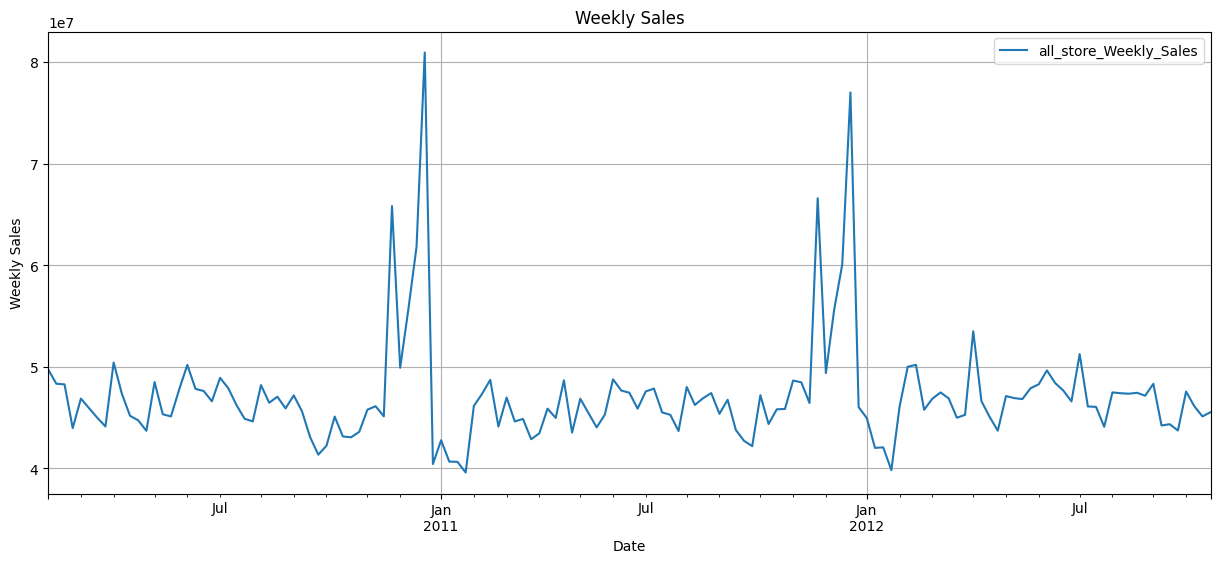

In [15]:
new_df.plot(kind='line',grid=True, figsize=(15, 6))
plt.title('Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()

In [16]:
new_df.isnull().sum()

all_store_Weekly_Sales    0
dtype: int64

In [17]:
new_df.index.year.unique()

Index([2010, 2011, 2012], dtype='int32', name='Date')

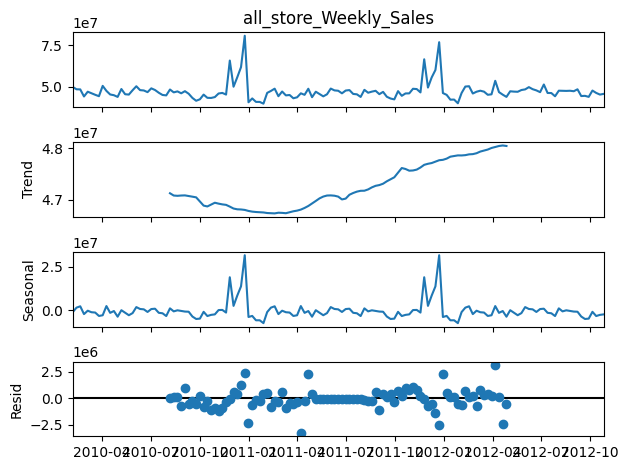

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(new_df['all_store_Weekly_Sales'], model='additive')
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid
decomposition.plot()
plt.show()

In [19]:
from statsmodels.tsa.stattools import adfuller

result =  adfuller(new_df['all_store_Weekly_Sales'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')

if result[1] > 0.05:
    print('The series is not stationary')
else:
    print('The series is stationary')

ADF Statistic: -5.908298
p-value: 0.000000
Critical Values:
The series is stationary


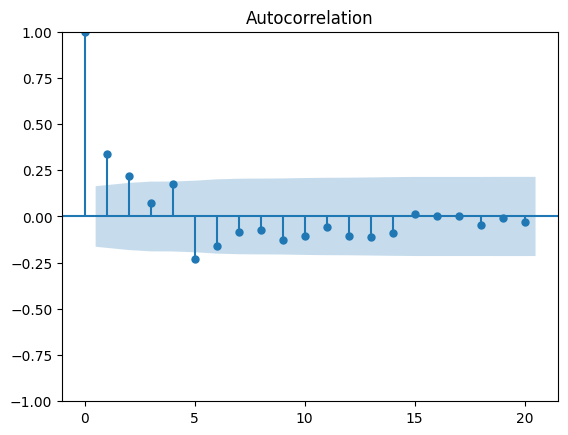

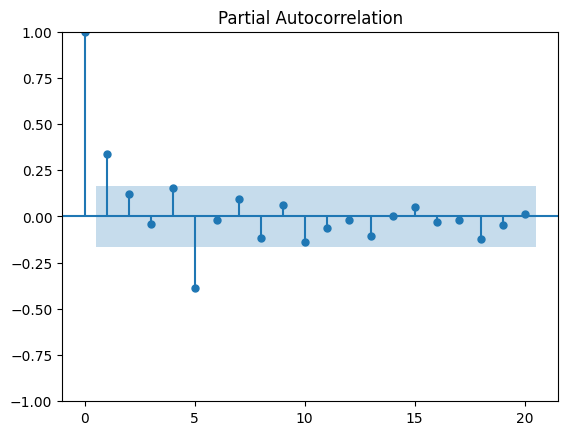

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(new_df['all_store_Weekly_Sales'], lags=20)
plot_pacf(new_df['all_store_Weekly_Sales'], lags=20)
plt.show()

In [21]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(new_df['all_store_Weekly_Sales'], order=(2,1,3)) # p = 2, d = 1, q = 3 from ACF-q and PACF-p
results = model.fit()
print(results.summary())

c:\Users\kumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\kumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\kumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:     all_store_Weekly_Sales   No. Observations:                  143
Model:                     ARIMA(2, 1, 3)   Log Likelihood               -2402.579
Date:                    Wed, 06 May 2026   AIC                           4817.159
Time:                            03:13:51   BIC                           4834.894
Sample:                        02-05-2010   HQIC                          4824.366
                             - 10-26-2012                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8590      0.153     -5.618      0.000      -1.159      -0.559
ar.L2         -0.2727      0.170     -1.606      0.108      -0.606       0.060
ma.L1          0.489

In [22]:
# !pip install pmdarima
from pmdarima import auto_arima

stepwise_fit = auto_arima(new_df['all_store_Weekly_Sales'], seasonal=True, trace=True)
print(stepwise_fit.summary())


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=4830.548, Time=0.33 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=4844.691, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=4829.490, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=4834.617, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=5462.768, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=4829.420, Time=0.06 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=4831.228, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=4831.381, Time=0.18 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=4830.601, Time=0.07 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=4833.224, Time=0.19 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0] intercept
Total fit time: 1.092 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  143
M

In [23]:
print(stepwise_fit.predict(n_periods=12))

2012-11-02    4.640702e+07
2012-11-09    4.671431e+07
2012-11-16    4.691026e+07
2012-11-23    4.700571e+07
2012-11-30    4.705783e+07
2012-12-07    4.708489e+07
2012-12-14    4.709924e+07
2012-12-21    4.710679e+07
2012-12-28    4.711077e+07
2013-01-04    4.711287e+07
2013-01-11    4.711397e+07
2013-01-18    4.711456e+07
Freq: W-FRI, dtype: float64


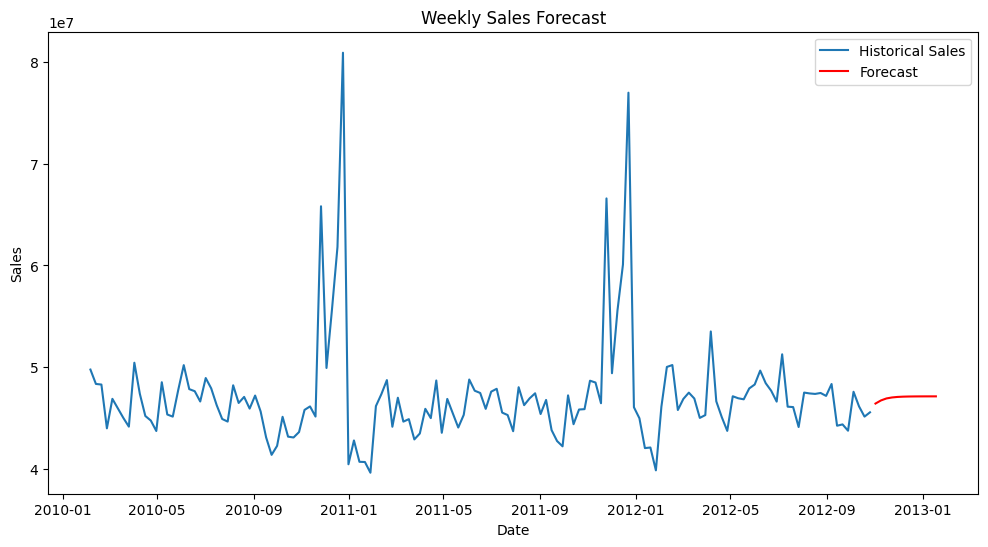

In [24]:
forecast = stepwise_fit.predict(n_periods=12)
plt.figure(figsize=(12, 6))
plt.plot(new_df.index, new_df['all_store_Weekly_Sales'], label='Historical Sales')

plt.plot(forecast.index, forecast, label='Forecast', color='red')

plt.title('Weekly Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [25]:
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit

In [26]:
df = pd.read_csv('train.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df.drop(['Store', 'Dept'],axis=1,inplace=True)
df = df.groupby(df.index).agg({'Weekly_Sales': 'sum', 'IsHoliday': 'max'})
df.rename(columns={'Weekly_Sales': 'all_store_Weekly_Sales', 'IsHoliday': 'IsHoliday'}, inplace=True)
df.head()

,all_store_Weekly_Sales,IsHoliday
Date,,
2010-02-05,49750740.50,False
2010-02-12,48336677.63,True
2010-02-19,48276993.78,False
2010-02-26,43968571.13,False
2010-03-05,46871470.30,False


In [27]:
new_df = df.copy()
new_df.head()

,all_store_Weekly_Sales,IsHoliday
Date,,
2010-02-05,49750740.50,False
2010-02-12,48336677.63,True
2010-02-19,48276993.78,False
2010-02-26,43968571.13,False
2010-03-05,46871470.30,False


In [28]:
new_df['lag1'] = new_df['all_store_Weekly_Sales'].shift(1)

new_df['lag2'] = new_df['all_store_Weekly_Sales'].shift(2)

new_df['lag3'] = new_df['all_store_Weekly_Sales'].shift(3)

new_df['lag4'] = new_df['all_store_Weekly_Sales'].shift(4)


new_df['moving_avg'] = new_df['all_store_Weekly_Sales'].rolling(window=4).mean()

new_df['moving_std'] = new_df['all_store_Weekly_Sales'].rolling(window=4).std()

In [29]:
new_df.columns

Index(['all_store_Weekly_Sales', 'IsHoliday', 'lag1', 'lag2', 'lag3', 'lag4',
       'moving_avg', 'moving_std'],
      dtype='object')

In [30]:
new_df.dropna(inplace=True)

new_df.head()

,all_store_Weekly_Sales,IsHoliday,lag1,lag2,lag3,lag4,moving_avg,moving_std
Date,,,,,,,,
2010-03-05,46871470.30,False,43968571.13,48276993.78,48336677.63,49750740.50,4.686343e+07,2.045230e+06
2010-03-12,45925396.51,False,46871470.30,43968571.13,48276993.78,48336677.63,4.626061e+07,1.807831e+06
2010-03-19,44988974.64,False,45925396.51,46871470.30,43968571.13,48276993.78,4.543860e+07,1.245423e+06
2010-03-26,44133961.05,False,44988974.64,45925396.51,46871470.30,43968571.13,4.547995e+07,1.181453e+06
2010-04-02,50423831.26,False,44133961.05,44988974.64,45925396.51,46871470.30,4.636804e+07,2.801089e+06


In [31]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 139 entries, 2010-03-05 to 2012-10-26
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   all_store_Weekly_Sales  139 non-null    float64
 1   IsHoliday               139 non-null    bool   
 2   lag1                    139 non-null    float64
 3   lag2                    139 non-null    float64
 4   lag3                    139 non-null    float64
 5   lag4                    139 non-null    float64
 6   moving_avg              139 non-null    float64
 7   moving_std              139 non-null    float64
dtypes: bool(1), float64(7)
memory usage: 8.8 KB


In [32]:
new_df.shape

(139, 8)

In [33]:
train = new_df[['lag1', 'lag2', 'lag3', 'lag4','moving_avg', 'moving_std', 'IsHoliday']]
test = new_df['all_store_Weekly_Sales']

x_train = train[:-12]
x_test = train[-12:]

y_train = test[:-12]
y_test = test[-12:]

In [34]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(127, 7)
(12, 7)
(127,)
(12,)


In [35]:
par_xgb ={
    'learning_rate': [0.1,0.2],
    'max_depth': [2, 3, 4],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 2]
}

xgb = XGBRegressor()
tscv = TimeSeriesSplit(n_splits=5)
grid_xgb = GridSearchCV(xgb, par_xgb, cv=tscv, n_jobs=-1, verbose=1,scoring='r2')
grid_xgb.fit(x_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.1, 0.2], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [50]:
print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 1.0}
-2.6089063004648643


In [56]:
importances = grid_xgb.best_estimator_.feature_importances_
print(importances)


[0.06413576 0.02688425 0.02299645 0.12670425 0.34312925 0.22269973
 0.19345027]


In [58]:

feat_imp = pd.Series(importances, index=x_train.columns)

print(feat_imp.sort_values(ascending=False))


moving_avg    0.343129
moving_std    0.222700
IsHoliday     0.193450
lag4          0.126704
lag1          0.064136
lag2          0.026884
lag3          0.022996
dtype: float32


In [37]:
y_pred = grid_xgb.predict(x_test)                               

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R2:', r2)

RMSE: 1067574.609123786
R2: 0.4865761136556854


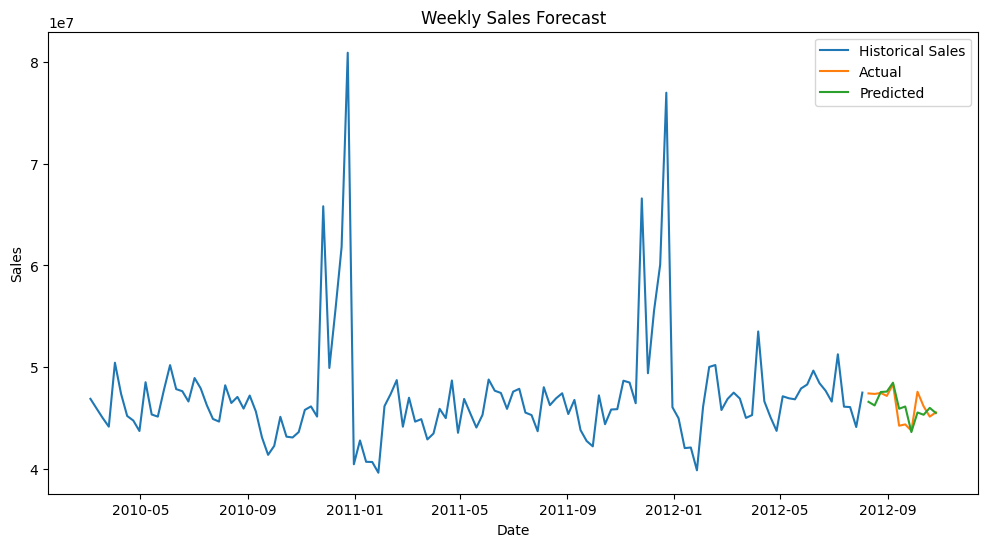

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Historical Sales')
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.title('Weekly Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

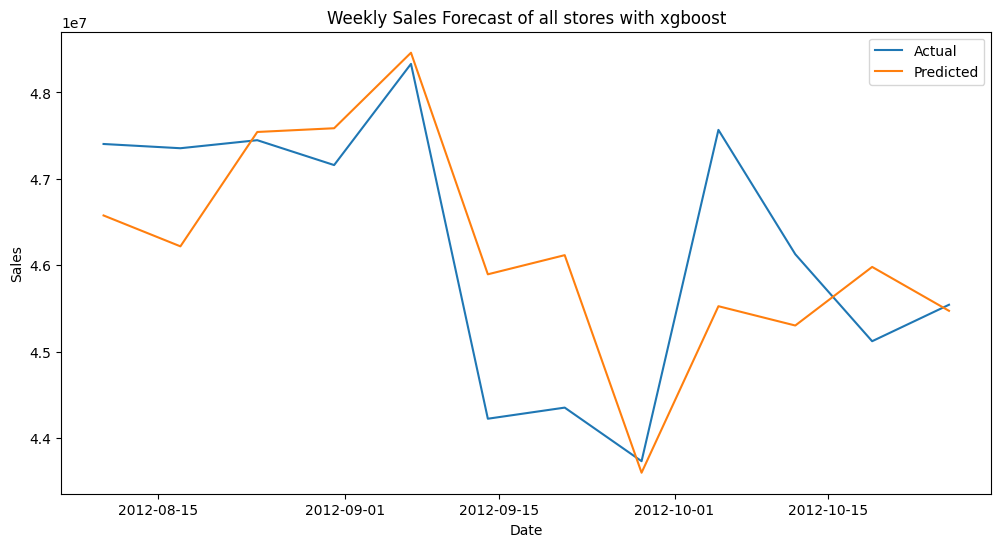

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.title('Weekly Sales Forecast of all stores with xgboost')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [45]:
par_rf = {
    'n_estimators': [100, 200, 1000],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3]
}

rf = RandomForestRegressor()
tscv = TimeSeriesSplit(n_splits=5)
grid_rf = GridSearchCV(rf, par_rf, cv=tscv, n_jobs=-1, verbose=1,scoring='r2')
grid_rf.fit(x_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [46]:
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 200}
-1.4125017324361049


In [47]:
y_pred = grid_rf.predict(x_test)                               

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R2:', r2)

RMSE: 1348033.034185243
R2: 0.18138317320995812


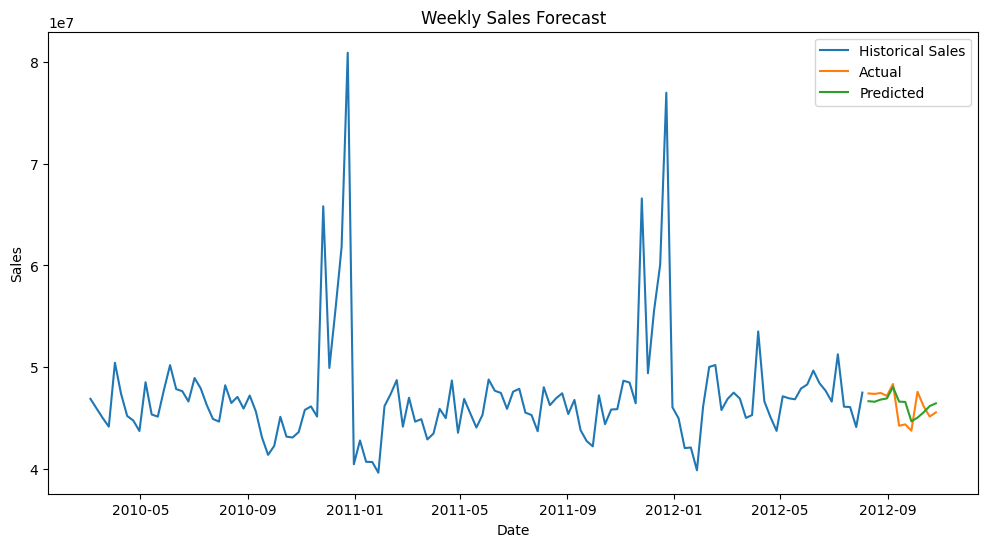

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Historical Sales')
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.title('Weekly Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

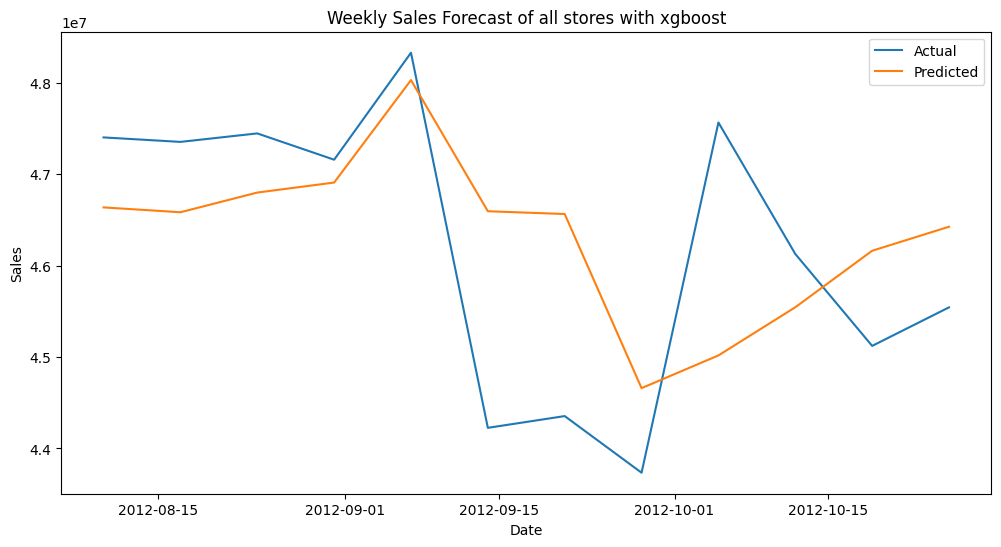

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.title('Weekly Sales Forecast of all stores with xgboost')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

xgboost have performed well 